### Regression Exercise 
# Moneyball The NBA
---

### This HW is not easy. TRY IT YOURSELF FIRST! 
Then If you are able to complete it, [watch this lecture series on it](https://ocw.mit.edu/courses/15-071-the-analytics-edge-spring-2017/pages/linear-regression/playing-moneyball-in-the-nba-recitation/video-1-the-data/). 

In [67]:
# PANDAS IS FOR DATA WRANGLING
import pandas as pd
import numpy as np

# SEABORN IS A PLOTTING LIBRARY
import seaborn as sns

# MATPLOT LIB IS ALSO A PLOTTING LIBRARY
import matplotlib.pyplot as plt

# SKLEARN IS OUR MACHINE LEARNING PACKAGE
from sklearn.linear_model import LinearRegression

# IMPORT OUR RANDOM FOREST REGERSSOR
from sklearn.ensemble import RandomForestRegressor

# METRICS HELP US SCORE OUR MODEL
from sklearn import metrics


# Good ol statsmodels
import statsmodels.api as sm

# Specific root mean squared error for stats models
from statsmodels.tools.eval_measures import rmse


from statsmodels.stats.outliers_influence import variance_inflation_factor


from statsmodels.api import qqplot

import CTPLIB as ctp


# Remember our main steps motto _isbe_.
1. i - Inspect and explore data.
2. s - Select and engineer features.
3. b - Build and train model.
4. e - Evaluate model.

# STEP 1 (i): Inspect and explore data
1. Use `data/NBA_test.csv and data/NBA_train.csv`

In [68]:
# READ IN THE DATA USING PANDAS 
df = pd.read_csv('data/NBA_train.csv')


# DISPLAY THE FIRST 5 ROWS
df.head()

,SeasonEnd,Team,Playoffs,W,PTS,oppPTS,FG,FGA,2P,2PA,3P,3PA,FT,FTA,ORB,DRB,AST,STL,BLK,TOV
0,1980,Atlanta Hawks,1,50,8573,8334,3261,7027,3248,6952,13,75,2038,2645,1369,2406,1913,782,539,1495
1,1980,Boston Celtics,1,61,9303,8664,3617,7387,3455,6965,162,422,1907,2449,1227,2457,2198,809,308,1539
2,1980,Chicago Bulls,0,30,8813,9035,3362,6943,3292,6668,70,275,2019,2592,1115,2465,2152,704,392,1684
3,1980,Cleveland Cavaliers,0,37,9360,9332,3811,8041,3775,7854,36,187,1702,2205,1307,2381,2108,764,342,1370
4,1980,Denver Nuggets,0,30,8878,9240,3462,7470,3379,7215,83,255,1871,2539,1311,2524,2079,746,404,1533


```
SeasonEnd: Year season ended
Team: Name of team
Playoffs: If they made the playoffs. 1 == made to playoffs
W: Number of regular season in that season. 
PTS: Points scored in regular season. 
oppPTS: Opponent Points scored in regular season. 
FG: Field Goals made (total shots made == 2P and 3P combined)
FGA: Field Goals attempted (total shots attempted == 2P and 3P combined)
2P: two-pointers made
2PA: two-pointers attempted
3P: three-pointers made
3PA: three-pointers attempted
FT: Free-Throws made (not included in FG stat)
FTA: Free-Throws attempted (not included in FG stat)
ORB: Offensive Rebounds
DRB: Defensive Rebounds
AST: Assists made
STL: Steals 
BLK: Blocks 
TOV: Turnovers 
```

#### Inspect our data using `df.describe()` function.

In [69]:
# Inspect our data using `df.describe()` function.
df.describe()

,SeasonEnd,Playoffs,W,PTS,oppPTS,FG,FGA,2P,2PA,3P,3PA,FT,FTA,ORB,DRB,AST,STL,BLK,TOV
count,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000
mean,1996.319760,0.574850,41.000000,8370.239521,8370.239521,3200.367665,6873.318563,2881.324551,5956.444311,319.043114,916.874251,1650.461078,2189.953293,1061.584431,2427.354491,1912.112575,668.364072,419.805988,1302.837126
std,9.243808,0.494662,12.740822,581.040114,587.543959,287.181266,401.027166,446.097941,830.596327,199.698941,523.982964,197.651728,244.491086,150.224519,130.671523,221.610925,93.393044,82.274913,153.973470
min,1980.000000,0.000000,11.000000,6901.000000,6909.000000,2565.000000,5972.000000,1981.000000,4153.000000,10.000000,75.000000,1189.000000,1475.000000,639.000000,2044.000000,1423.000000,455.000000,204.000000,931.000000
25%,1989.000000,0.000000,31.000000,7934.000000,7934.000000,2974.000000,6563.500000,2510.000000,5269.000000,131.500000,413.000000,1502.500000,2008.000000,953.500000,2346.500000,1735.000000,599.000000,359.000000,1192.000000
50%,1996.000000,1.000000,42.000000,8312.000000,8365.000000,3150.000000,6831.000000,2718.000000,5706.000000,329.000000,942.000000,1628.000000,2176.000000,1055.000000,2433.000000,1899.000000,658.000000,410.000000,1289.000000
75%,2005.000000,1.000000,50.500000,8784.500000,8768.500000,3434.500000,7157.000000,3296.000000,6753.500000,481.500000,1347.500000,1781.000000,2352.000000,1167.000000,2516.500000,2077.500000,729.000000,469.500000,1395.500000
max,2011.000000,1.000000,72.000000,10371.000000,10723.000000,3980.000000,8868.000000,3954.000000,7873.000000,841.000000,2284.000000,2388.000000,3051.000000,1520.000000,2753.000000,2575.000000,1053.000000,716.000000,1873.000000


#### Check for Nulls.

In [70]:
# Check for Nulls.
df.isnull().sum()

SeasonEnd    0
Team         0
Playoffs     0
W            0
PTS          0
oppPTS       0
FG           0
FGA          0
2P           0
2PA          0
3P           0
3PA          0
FT           0
FTA          0
ORB          0
DRB          0
AST          0
STL          0
BLK          0
TOV          0
dtype: int64

#### Check for Duplicates

In [71]:
# Check for Duplicates
df.duplicated().sum()

np.int64(0)

#### Build a function that will INSPECT ANY DATAFRAME FOR YOU do this for you for any data frame you pass into it.

In [72]:
print(df.dtypes)

SeasonEnd     int64
Team         object
Playoffs      int64
W             int64
PTS           int64
oppPTS        int64
FG            int64
FGA           int64
2P            int64
2PA           int64
3P            int64
3PA           int64
FT            int64
FTA           int64
ORB           int64
DRB           int64
AST           int64
STL           int64
BLK           int64
TOV           int64
dtype: object


In [73]:
for col in df.columns:
    if df[col].dtype == 'object':
        print(f"\nColumn: {col}")
        print(df[col].unique())


Column: Team
['Atlanta Hawks' 'Boston Celtics' 'Chicago Bulls' 'Cleveland Cavaliers'
 'Denver Nuggets' 'Detroit Pistons' 'Golden State Warriors'
 'Houston Rockets' 'Indiana Pacers' 'Kansas City Kings'
 'Los Angeles Lakers' 'Milwaukee Bucks' 'New Jersey Nets'
 'New York Knicks' 'Philadelphia 76ers' 'Phoenix Suns'
 'Portland Trail Blazers' 'San Antonio Spurs' 'San Diego Clippers'
 'Seattle SuperSonics' 'Utah Jazz' 'Washington Bullets' 'Dallas Mavericks'
 'Los Angeles Clippers' 'Sacramento Kings' 'Charlotte Hornets'
 'Miami Heat' 'Minnesota Timberwolves' 'Orlando Magic' 'Toronto Raptors'
 'Vancouver Grizzlies' 'Washington Wizards' 'Memphis Grizzlies'
 'New Orleans Hornets' 'Charlotte Bobcats'
 'New Orleans/Oklahoma City Hornets' 'Oklahoma City Thunder']


In [74]:
df['W'] = pd.to_numeric(df['W'], errors='coerce')

In [75]:
df = df.dropna(subset=['W'])

In [76]:
print(df.columns)


Index(['SeasonEnd', 'Team', 'Playoffs', 'W', 'PTS', 'oppPTS', 'FG', 'FGA',
       '2P', '2PA', '3P', '3PA', 'FT', 'FTA', 'ORB', 'DRB', 'AST', 'STL',
       'BLK', 'TOV'],
      dtype='object')


In [77]:
df.head()

,SeasonEnd,Team,Playoffs,W,PTS,oppPTS,FG,FGA,2P,2PA,3P,3PA,FT,FTA,ORB,DRB,AST,STL,BLK,TOV
0,1980,Atlanta Hawks,1,50,8573,8334,3261,7027,3248,6952,13,75,2038,2645,1369,2406,1913,782,539,1495
1,1980,Boston Celtics,1,61,9303,8664,3617,7387,3455,6965,162,422,1907,2449,1227,2457,2198,809,308,1539
2,1980,Chicago Bulls,0,30,8813,9035,3362,6943,3292,6668,70,275,2019,2592,1115,2465,2152,704,392,1684
3,1980,Cleveland Cavaliers,0,37,9360,9332,3811,8041,3775,7854,36,187,1702,2205,1307,2381,2108,764,342,1370
4,1980,Denver Nuggets,0,30,8878,9240,3462,7470,3379,7215,83,255,1871,2539,1311,2524,2079,746,404,1533


In [78]:
# Drop unnamed columns
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]


In [79]:
def inspect_dataframe(df):
    # 1. Basic Information
    print("\nBasic Information")
    print(f"Shape: {df.shape}")
    print("\nFirst 5 Rows:")
    print(df.head())
    print("\nData Types:")
    print(df.dtypes)
    print("\nMissing Values:")
    print(df.isnull().sum())
    # 2. Statistical Summary
    print("\nStatistical Summary")
    print(df.describe())

    # For categorical columns, provide descriptive statistics
    categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns
    if len(categorical_cols) > 0:
        print("\nStatistical Summary (Categorical)")
        print(df[categorical_cols].describe())

    # 3. Unique Values
    print("\n=== Unique Values ===")
    unique_counts = df.nunique()
    print(unique_counts)

    # Display top unique values for categorical columns
    if len(categorical_cols) > 0:
        print("\n=== Top Unique Values for Categorical Columns ===")
        for col in categorical_cols:
            print(f"\nColumn: {col}")
            print(df[col].value_counts().head())

    # 4. Correlation Matrix
    print("\n=== Correlation Matrix ===")
    
    # Select only numeric columns for correlation
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    corr = df[numeric_cols].corr()
    print(corr)

    # 6. Duplicates
    duplicate_count = df.duplicated().sum()
    print("\n=== Duplicate Rows ===")
    print(f"Total Duplicate Rows: {duplicate_count}")
    if duplicate_count > 0:
        print(df[df.duplicated()])
    print("\n=== Inspection Complete ===\n")



In [80]:
inspect_dataframe(df)


Basic Information
Shape: (835, 20)

First 5 Rows:
   SeasonEnd                 Team  Playoffs   W   PTS  oppPTS    FG   FGA  \
0       1980        Atlanta Hawks         1  50  8573    8334  3261  7027   
1       1980       Boston Celtics         1  61  9303    8664  3617  7387   
2       1980        Chicago Bulls         0  30  8813    9035  3362  6943   
3       1980  Cleveland Cavaliers         0  37  9360    9332  3811  8041   
4       1980       Denver Nuggets         0  30  8878    9240  3462  7470   

     2P   2PA   3P  3PA    FT   FTA   ORB   DRB   AST  STL  BLK   TOV  
0  3248  6952   13   75  2038  2645  1369  2406  1913  782  539  1495  
1  3455  6965  162  422  1907  2449  1227  2457  2198  809  308  1539  
2  3292  6668   70  275  2019  2592  1115  2465  2152  704  392  1684  
3  3775  7854   36  187  1702  2205  1307  2381  2108  764  342  1370  
4  3379  7215   83  255  1871  2539  1311  2524  2079  746  404  1533  

Data Types:
SeasonEnd     int64
Team         object
P

#### Get a sense of how many wins it will take to make the playoffs. 
Make a scatter plot with x=Wins and the y=Team, and the hue=Playoffs

In [81]:
print(df.columns)
print(df[['W', 'Team', 'Playoffs']].head())
print(df[['W', 'Team', 'Playoffs']].dtypes)


Index(['SeasonEnd', 'Team', 'Playoffs', 'W', 'PTS', 'oppPTS', 'FG', 'FGA',
       '2P', '2PA', '3P', '3PA', 'FT', 'FTA', 'ORB', 'DRB', 'AST', 'STL',
       'BLK', 'TOV'],
      dtype='object')
    W                 Team  Playoffs
0  50        Atlanta Hawks         1
1  61       Boston Celtics         1
2  30        Chicago Bulls         0
3  37  Cleveland Cavaliers         0
4  30       Denver Nuggets         0
W            int64
Team        object
Playoffs     int64
dtype: object


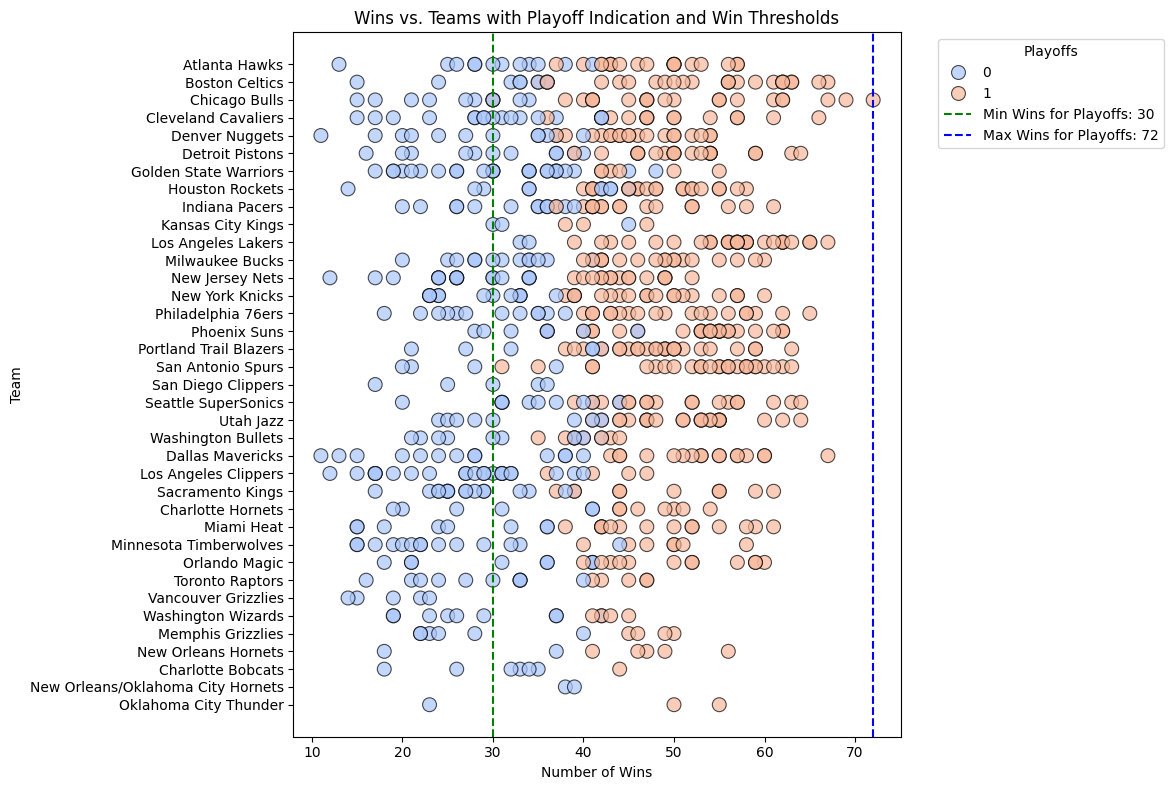

In [82]:
# Calculate the minimum and maximum number of wins for teams that made the playoffs
min_wins_playoff = df[df['Playoffs'] == 1]['W'].min()
max_wins_playoff = df[df['Playoffs'] == 1]['W'].max()

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df,
    x='W',
    y='Team',
    hue='Playoffs',
    palette='coolwarm',
    alpha=0.7,
    edgecolor='k',
    s=100
)

# Add vertical lines
plt.axvline(min_wins_playoff, color='green', linestyle='--', label=f'Min Wins for Playoffs: {min_wins_playoff}')
plt.axvline(max_wins_playoff, color='blue', linestyle='--', label=f'Max Wins for Playoffs: {max_wins_playoff}')

plt.title('Wins vs. Teams with Playoff Indication and Win Thresholds')
plt.xlabel('Number of Wins')
plt.ylabel('Team')
plt.legend(title='Playoffs', bbox_to_anchor=(1.05, 1), loc=2)
plt.tight_layout()
plt.show()


#### Take a rough estimate, and now use that moving forward.  



In [83]:
WINS_NEED_TO_MAKE_PLAYOFFS = df[df['Playoffs'] == 1]['W'].min()
print(f"Minimum wins needed to make playoffs: {WINS_NEED_TO_MAKE_PLAYOFFS}")

Minimum wins needed to make playoffs: 30


In [84]:
# Calculate the median number of wins among playoff teams
median_wins_playoff = df[df['Playoffs'] == 1]['W'].median()
print(f"Median wins needed to make playoffs: {median_wins_playoff}")


Median wins needed to make playoffs: 50.0


---

# Now do moneyball but for the NBA. 

#### I would like you to do try and do this on your own first.  

It's not easy, but its fun af.  

There is a guided lecture on how to do this that I can send you, but I'd like for you to try and figure it out on your own first.  

If you are fully stuck, ask in slack how other people did it if that doesn't work (I highly encourage collorbration and learning from eachother.  I still consider that doing it on your own.)  

If that doesn't work, DM me and I will send you the lectures explaining how to do the whole thing.

# Rough Guide a v1 model.
0. Make a model to predict PTS 
0. For v1, dont use `2P, 3P, FG, or FT`.  Instead use `2PA, 3PA, FTA`.  
0. Include any other cols use see fit.  


In [85]:
df_train = pd.read_csv('data/NBA_train.csv')
df_test = pd.read_csv('data/NBA_test.csv')
df_train.head()

,SeasonEnd,Team,Playoffs,W,PTS,oppPTS,FG,FGA,2P,2PA,3P,3PA,FT,FTA,ORB,DRB,AST,STL,BLK,TOV
0,1980,Atlanta Hawks,1,50,8573,8334,3261,7027,3248,6952,13,75,2038,2645,1369,2406,1913,782,539,1495
1,1980,Boston Celtics,1,61,9303,8664,3617,7387,3455,6965,162,422,1907,2449,1227,2457,2198,809,308,1539
2,1980,Chicago Bulls,0,30,8813,9035,3362,6943,3292,6668,70,275,2019,2592,1115,2465,2152,704,392,1684
3,1980,Cleveland Cavaliers,0,37,9360,9332,3811,8041,3775,7854,36,187,1702,2205,1307,2381,2108,764,342,1370
4,1980,Denver Nuggets,0,30,8878,9240,3462,7470,3379,7215,83,255,1871,2539,1311,2524,2079,746,404,1533


In [86]:
print(f"There are {df_train.duplicated().sum()} duplicates")
df_train.isnull().sum()
df_train.info()

There are 0 duplicates
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 835 entries, 0 to 834
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   SeasonEnd  835 non-null    int64 
 1   Team       835 non-null    object
 2   Playoffs   835 non-null    int64 
 3   W          835 non-null    int64 
 4   PTS        835 non-null    int64 
 5   oppPTS     835 non-null    int64 
 6   FG         835 non-null    int64 
 7   FGA        835 non-null    int64 
 8   2P         835 non-null    int64 
 9   2PA        835 non-null    int64 
 10  3P         835 non-null    int64 
 11  3PA        835 non-null    int64 
 12  FT         835 non-null    int64 
 13  FTA        835 non-null    int64 
 14  ORB        835 non-null    int64 
 15  DRB        835 non-null    int64 
 16  AST        835 non-null    int64 
 17  STL        835 non-null    int64 
 18  BLK        835 non-null    int64 
 19  TOV        835 non-null    int64 
dtypes: int64(

In [87]:
def inspect_dataframe(df_train):
    # 1. Basic Information
    print("\n=== Basic Information ===")
    print(f"Shape: {df.shape}")
    print("\nFirst 5 Rows:")
    print(df.head())
    print("\nData Types:")
    print(df.dtypes)
    print("\nMissing Values:")
    print(df.isnull().sum())

    # 2. Statistical Summary
    print("\n=== Statistical Summary (Numerical) ===")
    print(df.describe())

    # For categorical columns, provide descriptive statistics
    categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns
    if len(categorical_cols) > 0:
        print("\n=== Statistical Summary (Categorical) ===")
        print(df[categorical_cols].describe())

    # 3. Unique Values
    print("\n=== Unique Values ===")
    unique_counts = df.nunique()
    print(unique_counts)

    # Display top unique values for categorical columns
    if len(categorical_cols) > 0:
        print("\n=== Top Unique Values for Categorical Columns ===")
        for col in categorical_cols:
            print(f"\nColumn: {col}")
            print(df[col].value_counts().head())

    # 4. Correlation Matrix
    print("\n=== Correlation Matrix ===")
    
    # Select only numeric columns for correlation
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    corr = df[numeric_cols].corr()
    print(corr)


    # 6. Duplicates
    duplicate_count = df.duplicated().sum()
    print("\n=== Duplicate Rows ===")
    print(f"Total Duplicate Rows: {duplicate_count}")
    if duplicate_count > 0:
        print(df[df.duplicated()])

    print("\n=== Inspection Complete ===\n")

In [88]:
inspect_dataframe(df_train)


=== Basic Information ===
Shape: (835, 20)

First 5 Rows:
   SeasonEnd                 Team  Playoffs   W   PTS  oppPTS    FG   FGA  \
0       1980        Atlanta Hawks         1  50  8573    8334  3261  7027   
1       1980       Boston Celtics         1  61  9303    8664  3617  7387   
2       1980        Chicago Bulls         0  30  8813    9035  3362  6943   
3       1980  Cleveland Cavaliers         0  37  9360    9332  3811  8041   
4       1980       Denver Nuggets         0  30  8878    9240  3462  7470   

     2P   2PA   3P  3PA    FT   FTA   ORB   DRB   AST  STL  BLK   TOV  
0  3248  6952   13   75  2038  2645  1369  2406  1913  782  539  1495  
1  3455  6965  162  422  1907  2449  1227  2457  2198  809  308  1539  
2  3292  6668   70  275  2019  2592  1115  2465  2152  704  392  1684  
3  3775  7854   36  187  1702  2205  1307  2381  2108  764  342  1370  
4  3379  7215   83  255  1871  2539  1311  2524  2079  746  404  1533  

Data Types:
SeasonEnd     int64
Team         

In [89]:
print(df_train.isnull().sum())

SeasonEnd    0
Team         0
Playoffs     0
W            0
PTS          0
oppPTS       0
FG           0
FGA          0
2P           0
2PA          0
3P           0
3PA          0
FT           0
FTA          0
ORB          0
DRB          0
AST          0
STL          0
BLK          0
TOV          0
dtype: int64


In [98]:
# Initialize OneHotEncoder
encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# Fit the encoder on the training data and transform
encoded_train = encoder.fit_transform(df_train[['Team']])



In [97]:
# Store 'Team' names for plotting
team_names_train = df_train['Team'].copy()
team_names_test = df_test['Team'].copy()


In [99]:
# Transform the test data
encoded_test = encoder.transform(df_test[['Team']])


/Users/lucasyao/Documents/GitHub/my-fork-2024-fall-data-science/myenv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
